<a href="https://colab.research.google.com/github/skwotjd/2026_tues_bigdatacomputing_class/blob/main/%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  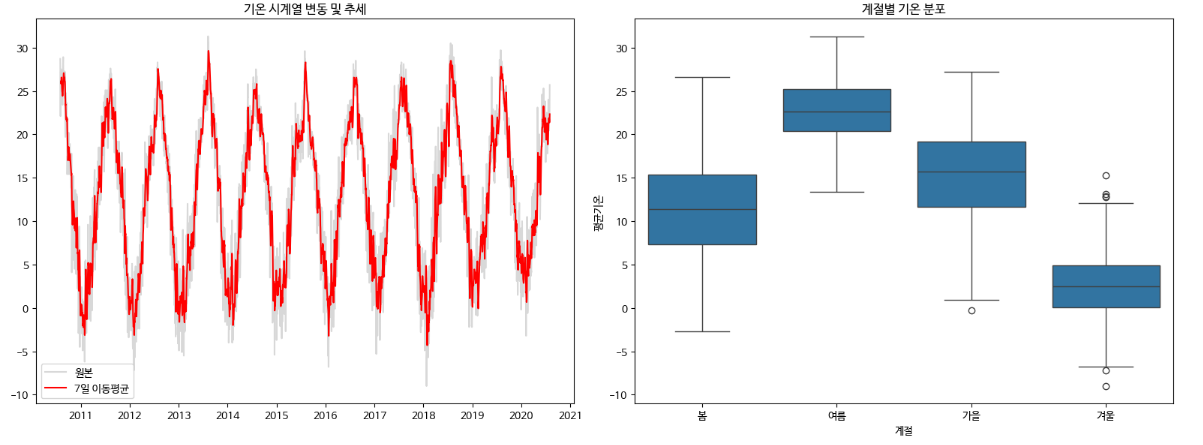

  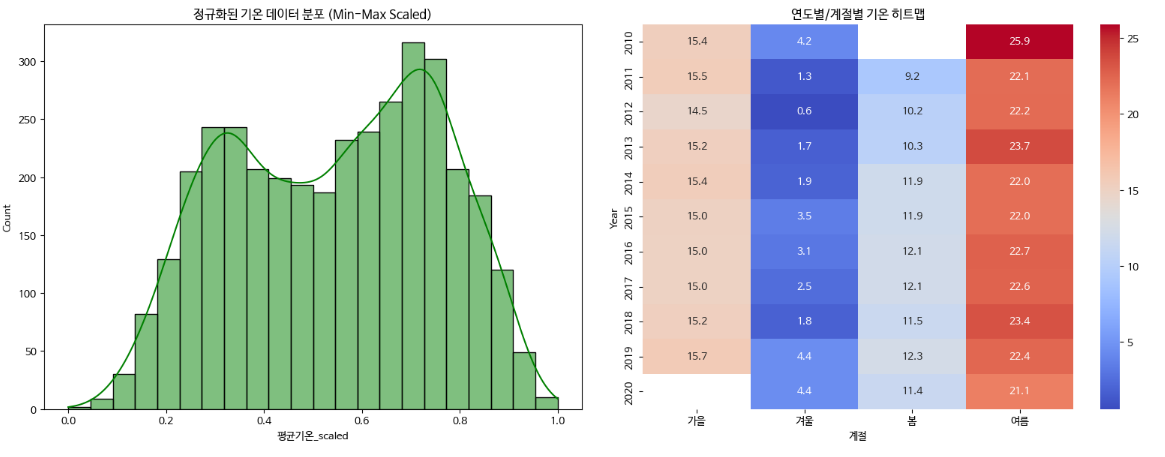



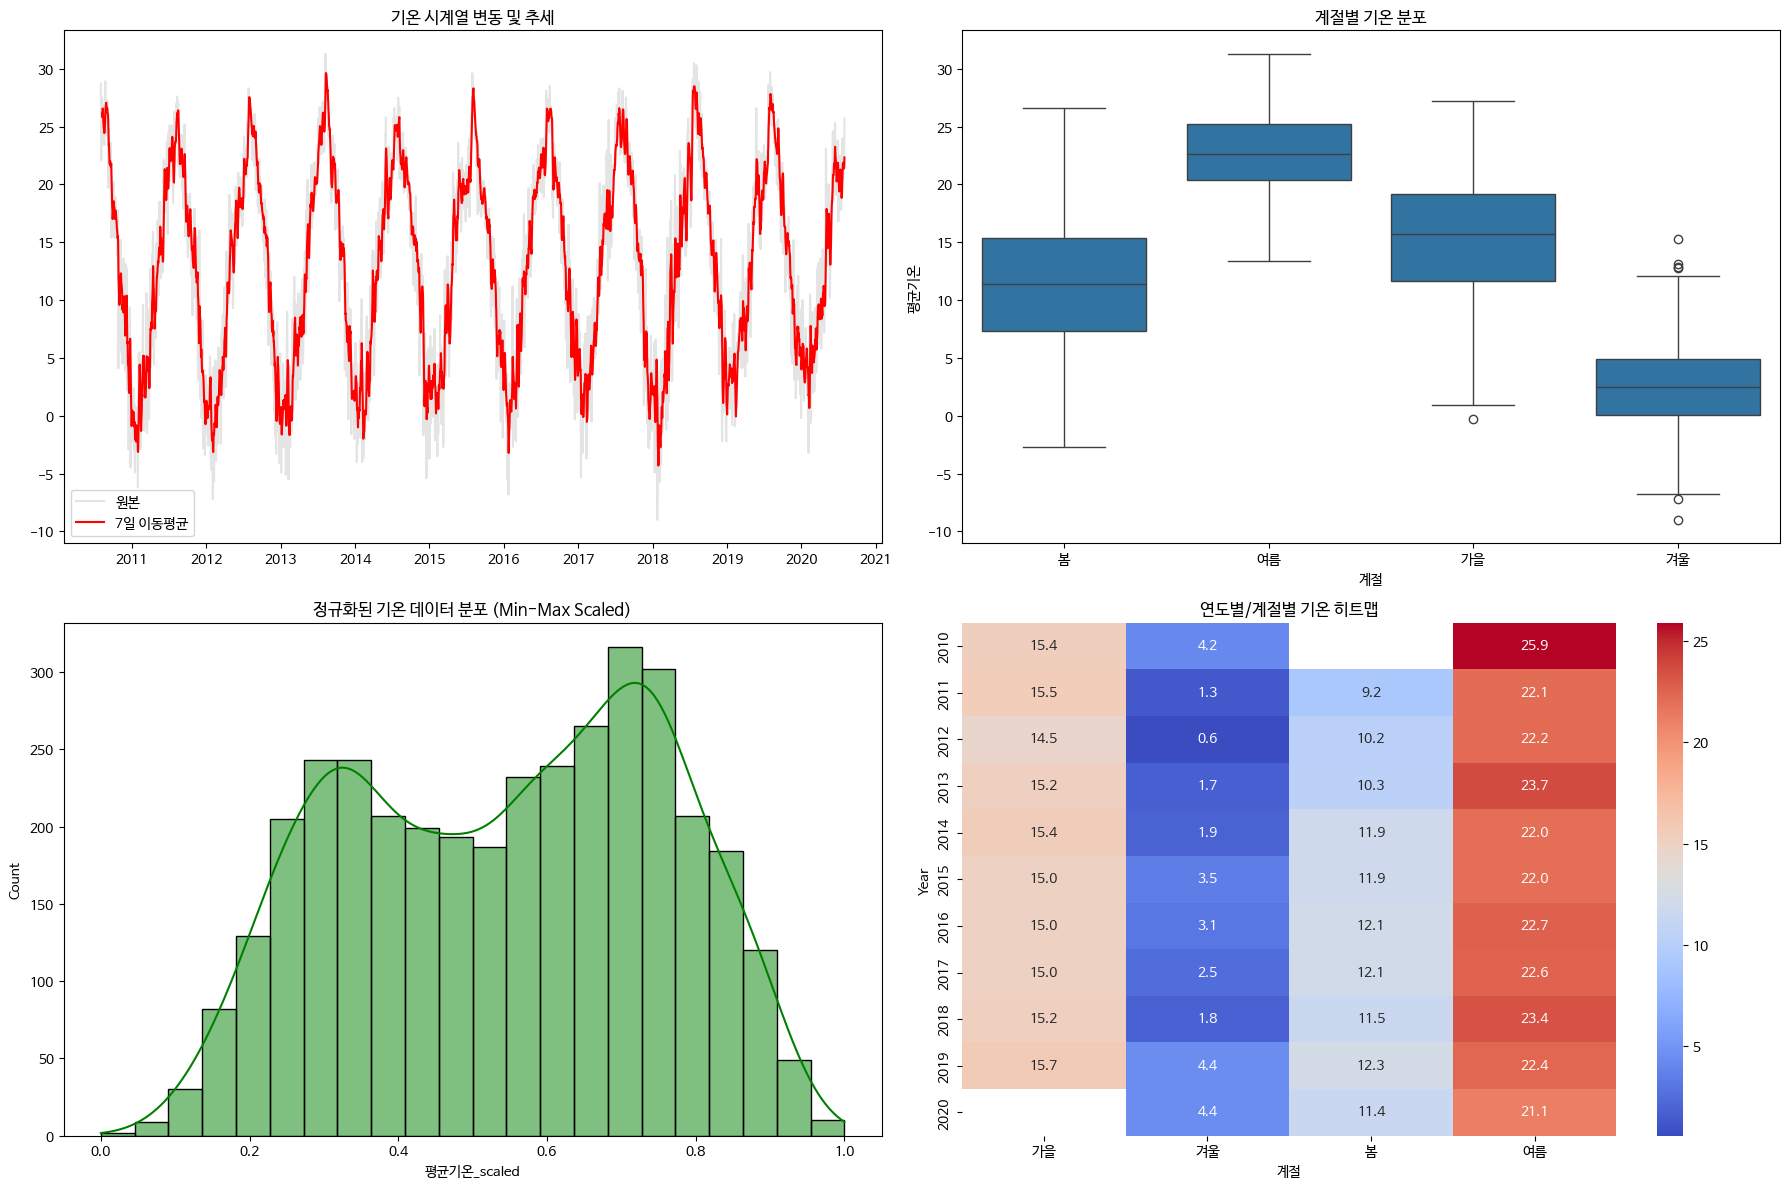

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.font_manager as fm

def setup_korean_font(): #한글 폰트 설정
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

    if not os.path.exists(font_path):
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')
    # 2. 폰트 매니저에 폰트 추가 (문제의 원인 해결)
    # FontProperties 대신 font_manager.fontManager.addfont를 사용.
    fm.fontManager.addfont(font_path)

    # 3. 전역 설정 적용
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False
#----------------------------------------------------------------------------------------
def data():
    global df
    url = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"
    df = pd.read_csv(url, encoding='cp949')
#----------------------------------------------------------------------------------------
def datetime_season():
    global df
    df['일시'] = pd.to_datetime(df['일시']) #시계열 데이터
    # print(df['일시'].dtype) 확인용
    df['7일 이동평균'] = df['평균기온'].rolling(window=7).mean() #7일 평균

    df['Year'] = df['일시'].dt.year #년도 추출
    df['Month'] = df['일시'].dt.month #달수 추출

    # 계절 컬럼
    def season(m): #엑셀에 필요함
        if 3 <= m <= 5: return '봄' #3월부터 5월은 봄
        elif 6 <= m <= 8: return '여름' #6월부터 8월은 여름
        elif 9 <= m <= 11: return '가을'  #9월부터 11월은 가을
        else: return '겨울' #나머진 겨울

    df['계절'] = df['Month'].apply(season)  #계절 컬럼 추가
#-----------------------------------------------------------------------------------------
def min_max_scalling():
    global df
    min_val = df['평균기온'].min()
    max_val = df['평균기온'].max()
    df['평균기온_scaled'] = (df['평균기온'] - min_val) / (max_val - min_val) #min-max scaling
#----------------------------------------------------------------------------------------
def pivot_table_temp():
    global seasonal_stats, pivot_report
    seasonal_stats = df.groupby('계절')['평균기온'].describe() #그룹바이

    pivot_report = df.pivot_table(values='평균기온', index='Year', columns='계절', aggfunc='mean') #피봇 테이블 자료 재구조
#----------------------------------------------------------------------------------------
def visual(): #시각화
    plt.figure(figsize=(18, 12))

    plt.subplot(2, 2, 1)
    plt.plot(df['일시'], df['평균기온'], color='lightgray', label='원본', alpha=0.6) #왼쪽 위
    plt.plot(df['일시'], df['7일 이동평균'], color='red', label='7일 이동평균')
    plt.title('기온 시계열 변동 및 추세')
    plt.legend()

    plt.subplot(2, 2, 2)
    sns.boxplot(x='계절', y='평균기온', data=df, order=['봄', '여름', '가을', '겨울']) #오른쪽 위
    plt.title('계절별 기온 분포')

    plt.subplot(2, 2, 3)
    sns.histplot(df['평균기온_scaled'], kde=True, color='green')  #왼쪽 아래
    plt.title('정규화된 기온 데이터 분포 (Min-Max Scaled)')

    plt.subplot(2, 2, 4)
    sns.heatmap(pivot_report, annot=True, fmt=".1f", cmap='coolwarm') #오른쪽 아래
    plt.title('연도별/계절별 기온 히트맵')

    plt.tight_layout()
    plt.show()
#----------------------------------------------------------------------------------------
def export_to():
    with pd.ExcelWriter('weather_analysis_report.xlsx') as writer: #별도 시트 저장.
        df.to_excel(writer, sheet_name='전처리 데이터', index=False)
        seasonal_stats.to_excel(writer, sheet_name='계절별 통계')
        pivot_report.to_excel(writer, sheet_name='연도별 피벗 테이블')
#----------------------------------------------------------------------------------------
def main():
    setup_korean_font() #폰트
    data() #데이터
    datetime_season() #계절,시계열 설정
    min_max_scalling() #스칼링
    pivot_table_temp() #피봇테이블
    visual() #시각화
    export_to() #엑셀로 내보내기
#----------------------------------------------------------------------------------------
# 실행
if __name__ == "__main__":
    main()